**This notebook is generated just to learn how neural networks are made before starting to learn Backpropagation**

In [2]:
# importing the dataset
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('Churn_Modelling.csv')
print(df.shape)

(10000, 14)


In [6]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [7]:
df.drop(['RowNumber','CustomerId','Surname'],axis=1 ,inplace=True)

In [8]:
# let us look at the basic statistic
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


<Axes: xlabel='Geography'>

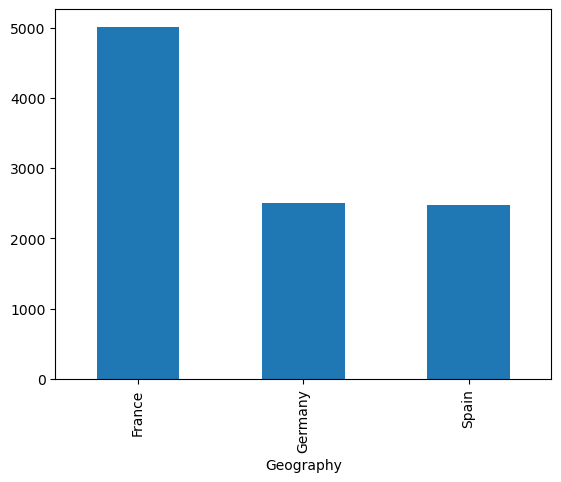

In [10]:
df['Geography'].value_counts().plot(kind='bar')

<Axes: xlabel='Gender'>

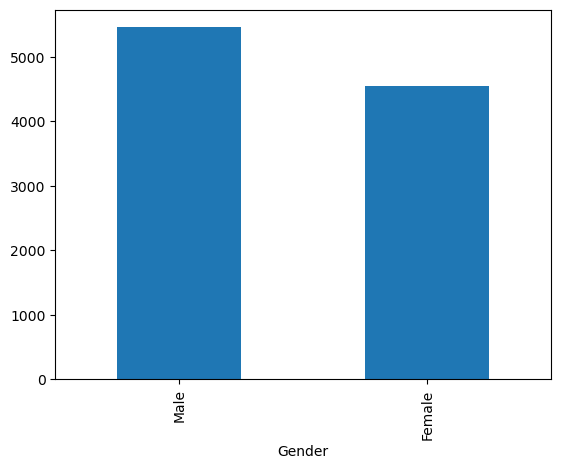

In [11]:
df['Gender'].value_counts().plot(kind='bar')

<Axes: xlabel='Exited'>

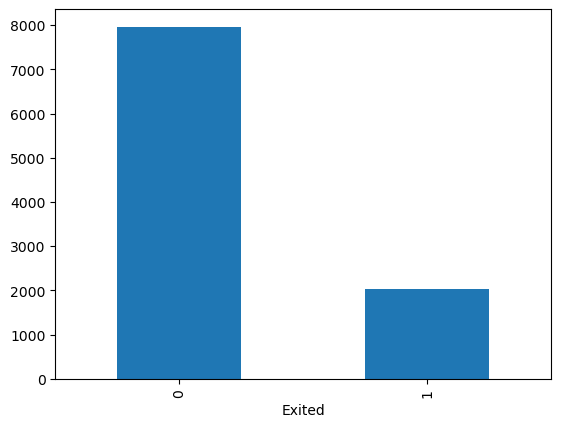

In [12]:
df['Exited'].value_counts().plot(kind='bar')

- we see an imbalance here, but we will not worry about it here

In [32]:
# Changing the Nominal Columns to OHE
df = pd.get_dummies(df,columns=['Geography','Gender'], drop_first=True , dtype='int')

In [33]:
from sklearn.model_selection import train_test_split
X = df.drop('Exited',axis=1)
y = df['Exited']
print(X.shape)
print(y.shape)

(10000, 11)
(10000,)


In [34]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.2 , random_state=42, stratify = y)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(8000, 11)
(8000,)
(2000, 11)
(2000,)


In [35]:
X_train.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
2151,753,57,7,0.00,1,1,0,159475.08,0,0,1
8392,739,32,3,102128.27,1,1,0,63981.37,1,0,1
5006,755,37,0,113865.23,2,1,1,117396.25,1,0,0
4117,561,37,5,0.00,2,1,0,83093.25,0,0,1
7182,692,49,6,110540.43,2,0,1,107472.99,1,0,1


In [44]:
# Standardizing the Data
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()
X_train_scaled = scale.fit_transform(X_train)
X_test_scaled = scale.transform(X_test)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(8000, 11)
(2000, 11)


In [37]:
# Let us now start building our basic Neural Network (Sequential Model)
# %pip install tensorflow
# %pip install keras
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense


In [38]:
model = Sequential()

In [39]:
model.add(Dense(3, activation='sigmoid',input_dim = 11))
model.add(Dense(1,activation='sigmoid'))

c:\Users\Pradhuman\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [40]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 3)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40 (160.00 B)

 Trainable params: 40 (160.00 B)

 Non-trainable params: 0 (0.00 B)

In [41]:
model.compile(loss='binary_crossentropy', optimizer='Adam')

In [45]:
model.fit(X_train_scaled,y_train , epochs=20)

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.6568
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5373
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4867
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4640
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4517
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4440
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4387
Epoch 8/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4350
Epoch 9/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4324
Epoch 10/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4305
Epoch 11/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4290
Epoch 12/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4278
Epoch 13/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4268
Epoch 14/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4258
Epoch 15/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - lo

In [46]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 3)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122 (492.00 B)

 Trainable params: 40 (160.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 82 (332.00 B)

In [ ]:
model.layers[0].get_weights()  # this is the weights and bias of 1st hidden layer

[array([[ 1.1950151e-01, -2.1617815e-02,  1.9404528e-01],
        [-2.0459528e+00,  2.6939574e-01, -1.0631019e+00],
        [ 1.0605926e-01,  3.3010560e-01,  1.7264953e-01],
        [ 6.6203035e-02,  5.4239458e-01, -4.3837446e-01],
        [ 1.6160747e-01, -3.6169663e-02, -5.6077796e-04],
        [ 3.9656591e-02,  2.0096641e-02,  4.4192787e-02],
        [ 2.1830961e-01, -9.4566894e-01,  8.4017903e-01],
        [ 1.9496214e-01,  4.1957441e-01, -2.2128269e-01],
        [-3.2155108e-01,  5.3579015e-01, -8.1493729e-01],
        [-1.6382281e-01, -4.5385573e-02,  2.3891017e-01],
        [ 1.0953663e-01, -7.3357058e-01,  5.0359654e-01]], dtype=float32),
 array([ 0.35390154, -0.37408948,  0.50331944], dtype=float32)]

In [ ]:
model.layers[1].get_weights() # this is the 2nd layer (output layer)

[array([[-1.9257922],
        [ 1.0306244],
        [-1.0670737]], dtype=float32),
 array([-0.34683797], dtype=float32)]

In [50]:
y_log = model.predict(X_test_scaled) # these are probabilities of being 1 since our activation -> sigmoid

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [51]:
y_pred = np.where(y_log>0.5 , 1, 0)

In [52]:
y_pred

array([[0],
       [0],
       [0],
       ...,
       [1],
       [0],
       [0]], shape=(2000, 1))

In [ ]:
# Now let us check the accuracy score
from sklearn.metrics import accuracy_score
print(f'Accuracy -> {accuracy_score(y_test , y_pred)}') # 0.815 when we have 1 hidden (3 nodes) 1 output(1 node)

Accuracy -> 0.815


In [54]:
# Let us increase the complexity of our model
# We will have 2 hidden layers of 3 nodes each + output layer(1 node)
model_2 = Sequential()

model_2.add(Dense(3, activation='sigmoid', input_dim = 11)) # First hidden layer connected to input layer
model_2.add(Dense(3, activation='sigmoid' , input_dim = 3)) # connected to first hidden layer
model_2.add(Dense(1 , activation='sigmoid')) # output layer

c:\Users\Pradhuman\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [55]:
model_2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 3)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52 (208.00 B)

 Trainable params: 52 (208.00 B)

 Non-trainable params: 0 (0.00 B)

In [61]:
model_2.compile(loss='binary_crossentropy', optimizer='Adam')

model_2.fit(X_train_scaled , y_train)

250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.6193


In [62]:
model_2.layers[0].get_weights() # total 33 + 3

[array([[ 0.4070869 ,  0.29903182, -0.42662638],
        [-0.76507825,  0.22676578, -0.00407198],
        [ 0.27405986, -0.5391425 ,  0.404129  ],
        [ 0.21301292,  0.12990375, -0.40395215],
        [ 0.51422703,  0.08235722,  0.2552847 ],
        [-0.2203492 , -0.29445747, -0.29481974],
        [-0.46074528,  0.41453525,  0.03114369],
        [ 0.2629254 ,  0.36475655, -0.13674773],
        [ 0.36995924, -0.28390113,  0.64563954],
        [ 0.6090149 , -0.2856135 , -0.05825921],
        [-0.24039699,  0.17742248, -0.45174047]], dtype=float32),
 array([ 0.19656292,  0.19534172, -0.16038801], dtype=float32)]

In [ ]:
model_2.layers[1].get_weights() # 9 +3

[array([[ 0.64060086,  0.8333247 ,  0.6849917 ],
        [-0.57859504, -0.07499069, -0.6172027 ],
        [-0.20433612, -0.22826615,  0.24930526]], dtype=float32),
 array([-0.18923947,  0.21834855,  0.08464144], dtype=float32)]

In [ ]:
model_2.layers[2].get_weights() # finally 3 + 1

[array([[ 0.405271  ],
        [-0.8487802 ],
        [-0.12875706]], dtype=float32),
 array([-0.20683235], dtype=float32)]

In [65]:
y_log2 = model_2.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [66]:
y_pred2 = np.where(y_log2>0.5,1,0)

In [ ]:
print(f'accuracy_score -> {accuracy_score(y_test , y_pred2)}') # accuracy decreased from 0.815 to 0.7965

accuracy_score -> 0.7965


### Using ReLU as the activation Function

In [85]:
model = Sequential()
model.add(Dense(16, activation='relu',input_dim = 11))
model.add(Dense(8, activation='relu')) # no need to give the input dimension here (keras knows it!!)
model.add(Dense(1,activation='sigmoid'))
model.summary()
model.compile(loss='binary_crossentropy', optimizer='Adam',metrics=['accuracy'])
history = model.fit(X_train_scaled,y_train , epochs=100,validation_split=.2)
model.summary()
model.layers[0].get_weights()  # this is the weights and bias of 1st hidden layer
model.layers[1].get_weights() # this is the 2nd layer (output layer)
y_log = model.predict(X_test_scaled) # these are probabilities of being 1 since our activation -> sigmoid
y_pred = np.where(y_log>0.5 , 1, 0)
y_pred
# Now let us check the accuracy score
from sklearn.metrics import accuracy_score
print(f'Accuracy -> {accuracy_score(y_test , y_pred)}')

c:\Users\Pradhuman\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_51 (Dense)                │ (None, 16)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 337 (1.32 KB)

 Trainable params: 337 (1.32 KB)

...

 Total params: 1,013 (3.96 KB)

 Trainable params: 337 (1.32 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 676 (2.64 KB)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Accuracy -> 0.8635


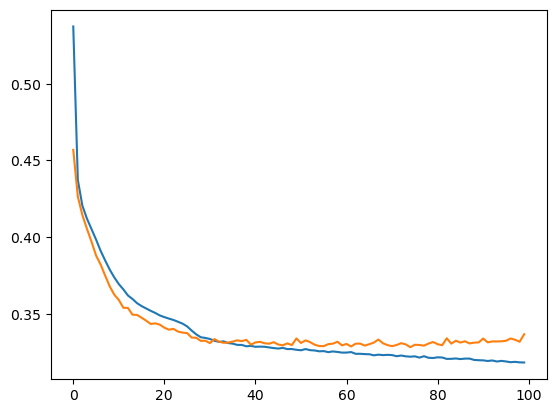

In [86]:
import matplotlib.pyplot as plt 
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss']) # this is a classic overfitting

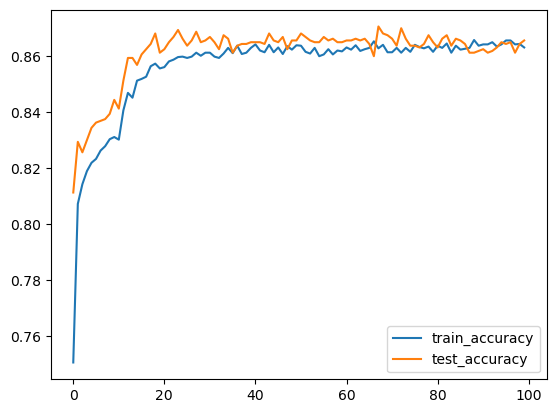

In [89]:
plt.plot(history.history['accuracy'],label='train_accuracy')
plt.plot(history.history['val_accuracy'],label='test_accuracy') # this is actually a great result !! NO OVERFITTING FOUND!
plt.legend()